In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
gecco_df = pd.read_csv("../gecco/1_gecco2018_water_quality.csv", index_col=0)
gecco_df.head()

,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
1,2016-08-03 11:49:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1677.0,695.0,False
2,2016-08-03 11:50:00,6.5,0.17,8.36,749.0,211.0,0.011,0.118,1561.0,696.0,False
3,2016-08-03 11:51:00,6.5,0.17,8.35,749.0,211.0,0.011,0.117,1581.0,696.0,False
4,2016-08-03 11:52:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1579.0,693.0,False
5,2016-08-03 11:53:00,6.5,0.17,8.35,749.0,211.0,0.011,0.118,1567.0,689.0,False


In [3]:
gecco_df.shape

(139566, 11)

In [4]:
# total time
time_series = pd.to_datetime(gecco_df['Time'])
time_series.iloc[-1].date() - time_series.iloc[0].date()

datetime.timedelta(days=97)

In [5]:
# total anomalies
gecco_df['EVENT'].value_counts()

EVENT
False    137840
True       1726
Name: count, dtype: int64

In [6]:
# anomaly percentage
anomaly_percentage = gecco_df['EVENT'].value_counts(normalize=True) * 100
anomaly_percentage

EVENT
False    98.763309
True      1.236691
Name: proportion, dtype: float64

In [7]:
# anomalies per day
gecco_df['Time'] = pd.to_datetime(gecco_df['Time'])
anomalies_per_day = gecco_df[gecco_df['EVENT'] == 1].groupby(gecco_df['Time'].dt.date).size()
anomalies_per_day

Time
2016-08-14     35
2016-08-15     56
2016-08-16     53
2016-08-31     21
2016-09-01     42
2016-09-02     21
2016-09-03     21
2016-09-07    198
2016-09-14    253
2016-09-16     10
2016-09-17     44
2016-09-18    132
2016-09-19    110
2016-09-22    157
2016-09-24     46
2016-09-25    115
2016-09-26    138
2016-09-27     23
2016-10-06     58
2016-10-07     29
2016-10-08     29
2016-10-09     29
2016-10-10     29
2016-11-03     77
dtype: int64

In [8]:
# timestamp per day
timestamps_per_day = gecco_df.groupby(gecco_df['Time'].dt.date).size()
timestamps_per_day.value_counts()

1440    95
731      1
1500     1
535      1
Name: count, dtype: int64

In [9]:
# find days with timecount not equal to 1440
days_with_incomplete_data = timestamps_per_day[timestamps_per_day != 1440]
days_with_incomplete_data

Time
2016-08-03     731
2016-10-30    1500
2016-11-08     535
dtype: int64

In [10]:
# create df from date 2016-08-03 to 2016-10-30
df = gecco_df[(gecco_df['Time'] >= '2016-08-04 00:00:00') & (gecco_df['Time'] < '2016-10-30 00:00:00')]
df.head()

,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
732,2016-08-04 00:00:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1469.0,805.0,False
733,2016-08-04 00:01:00,6.5,0.17,8.41,748.0,211.0,0.018,0.108,1435.0,811.0,False
734,2016-08-04 00:02:00,6.5,0.17,8.41,748.0,211.0,0.017,0.109,1423.0,806.0,False
735,2016-08-04 00:03:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1425.0,814.0,False
736,2016-08-04 00:04:00,6.5,0.17,8.41,747.0,211.0,0.017,0.109,1445.0,809.0,False


In [11]:
df.to_csv("gacco_cleaned.csv", index=False)

In [12]:
days_with_incomplete_data = df.groupby(df['Time'].dt.date).size()
days_with_incomplete_data = days_with_incomplete_data[days_with_incomplete_data != 1440]
days_with_incomplete_data

Series([], dtype: int64)

In [13]:
days_with_complete_data = timestamps_per_day[timestamps_per_day == 1440]
days_with_complete_data.shape

(95,)

In [14]:
# extract dataframe for days with timestep count equal to 1500
gecco_df_filtered = gecco_df[gecco_df['Time'].dt.date.isin(days_with_incomplete_data[days_with_incomplete_data == 1500].index)]
# gecco_df_filtered.to_csv("1500_timestep_data.csv", index=False)

# find repeated timestamps in the filtered dataframe
repeated_timestamps = gecco_df_filtered[gecco_df_filtered.duplicated(subset=['Time'], keep=False)]
repeated_timestamps


,Time,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT


In [15]:
gecco_df_complete = gecco_df[gecco_df['Time'].dt.date == pd.Timestamp('2016-09-07').date()]
gecco_df_complete.to_csv("gecco_complete_data.csv", index=False)
gecco_df_complete.shape

(1440, 11)

In [16]:
count = gecco_df_complete[gecco_df_complete["EVENT"] == 1]
count.shape

(198, 11)

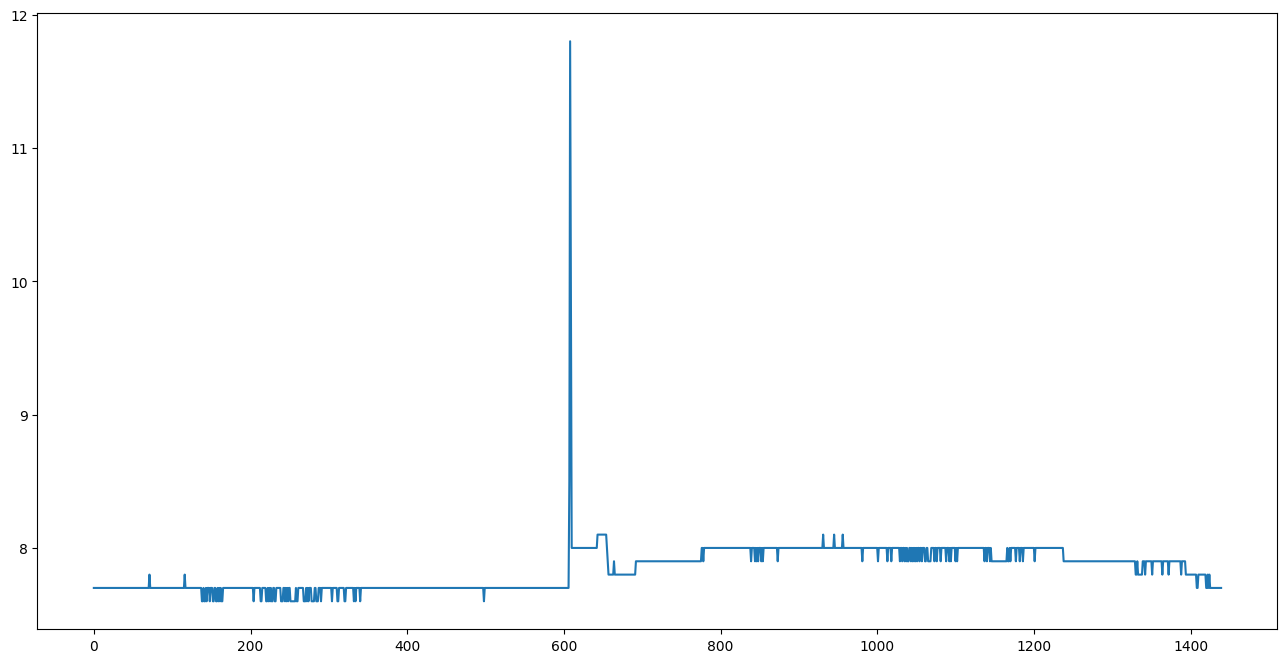

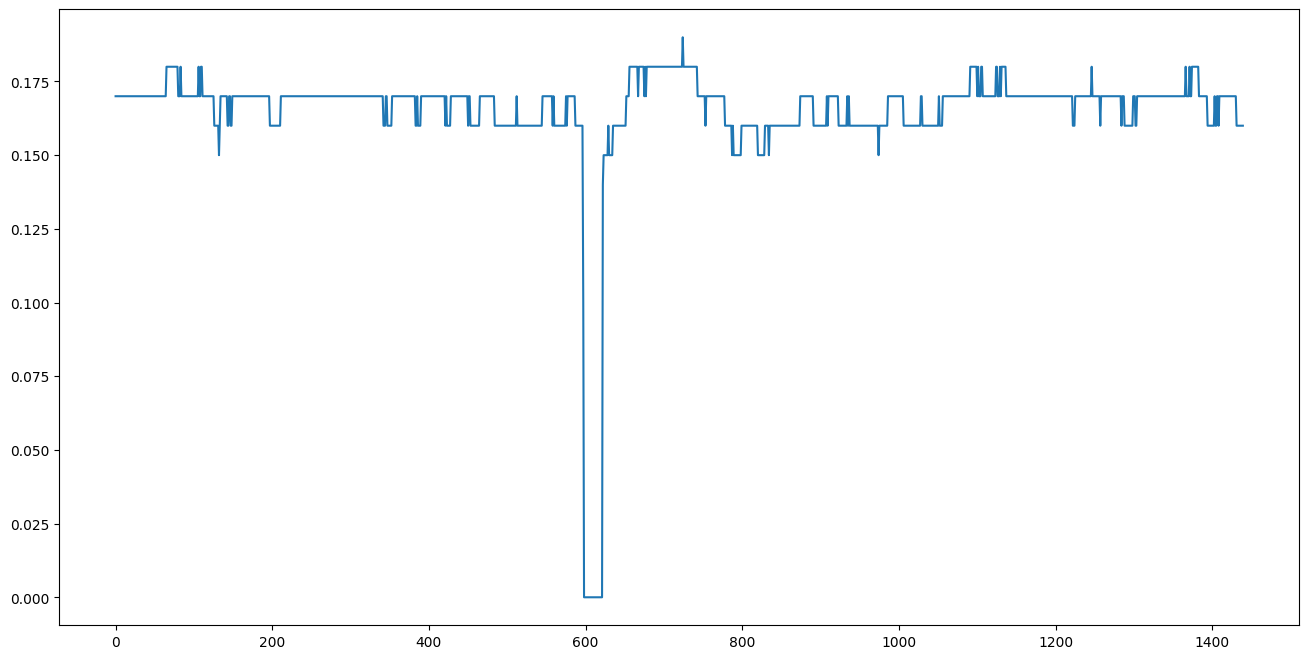

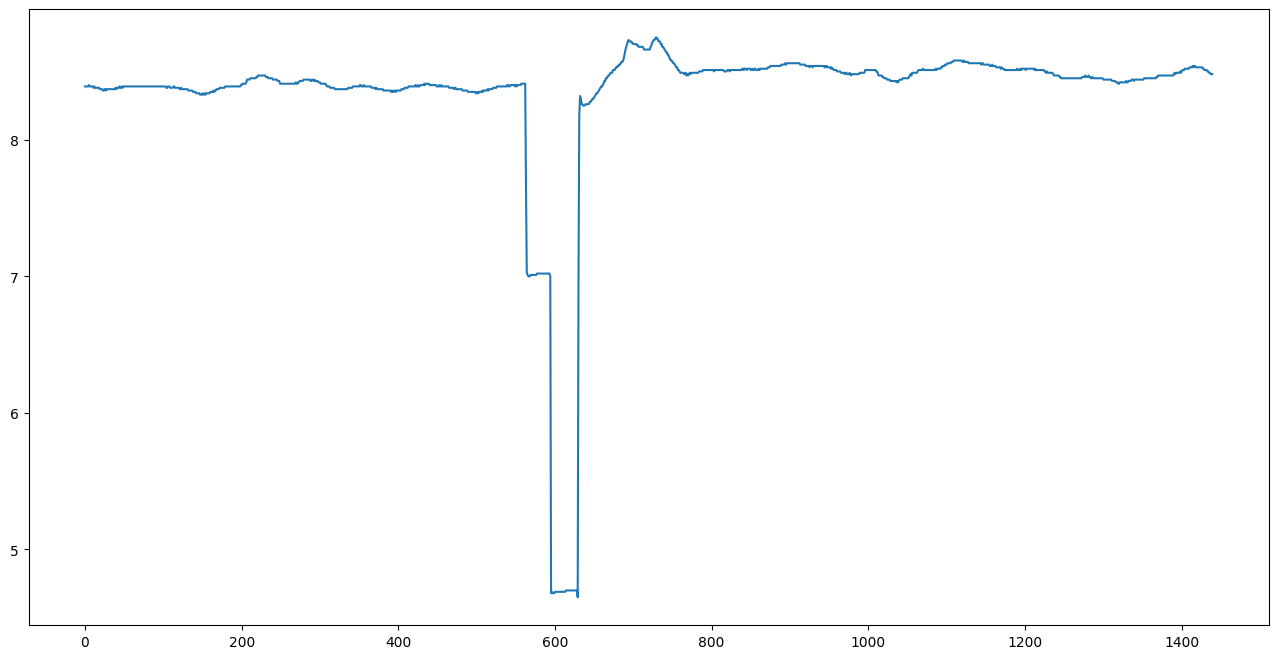

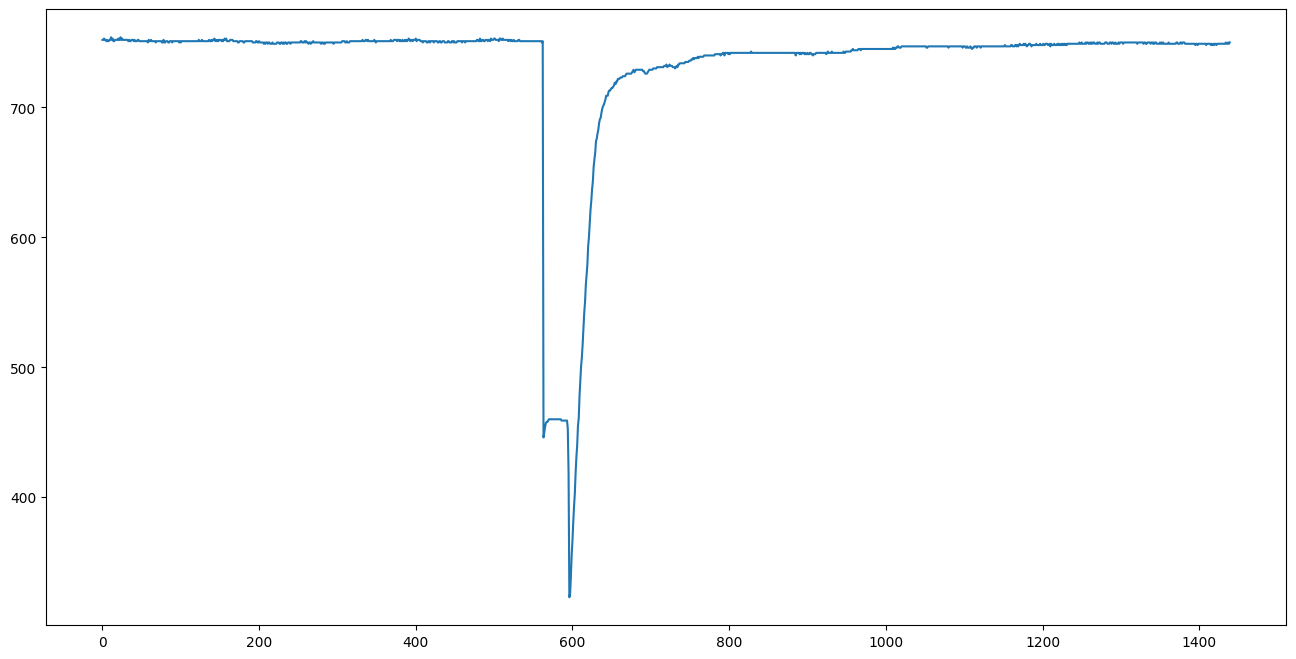

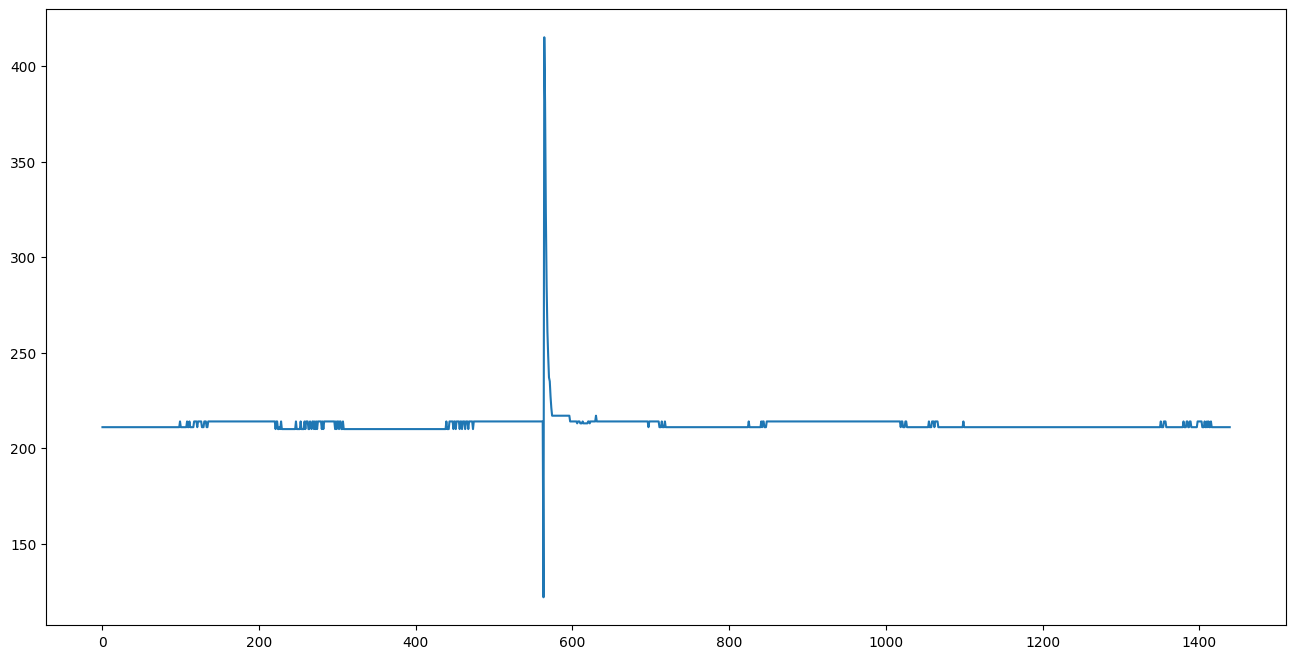

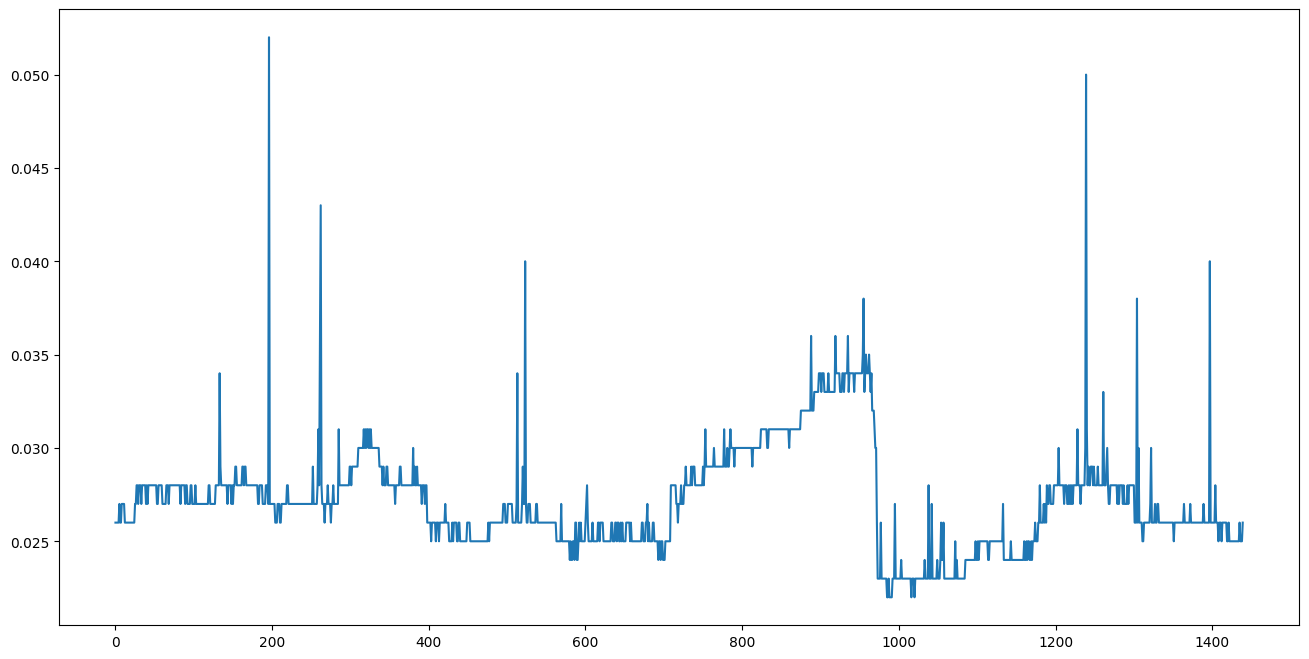

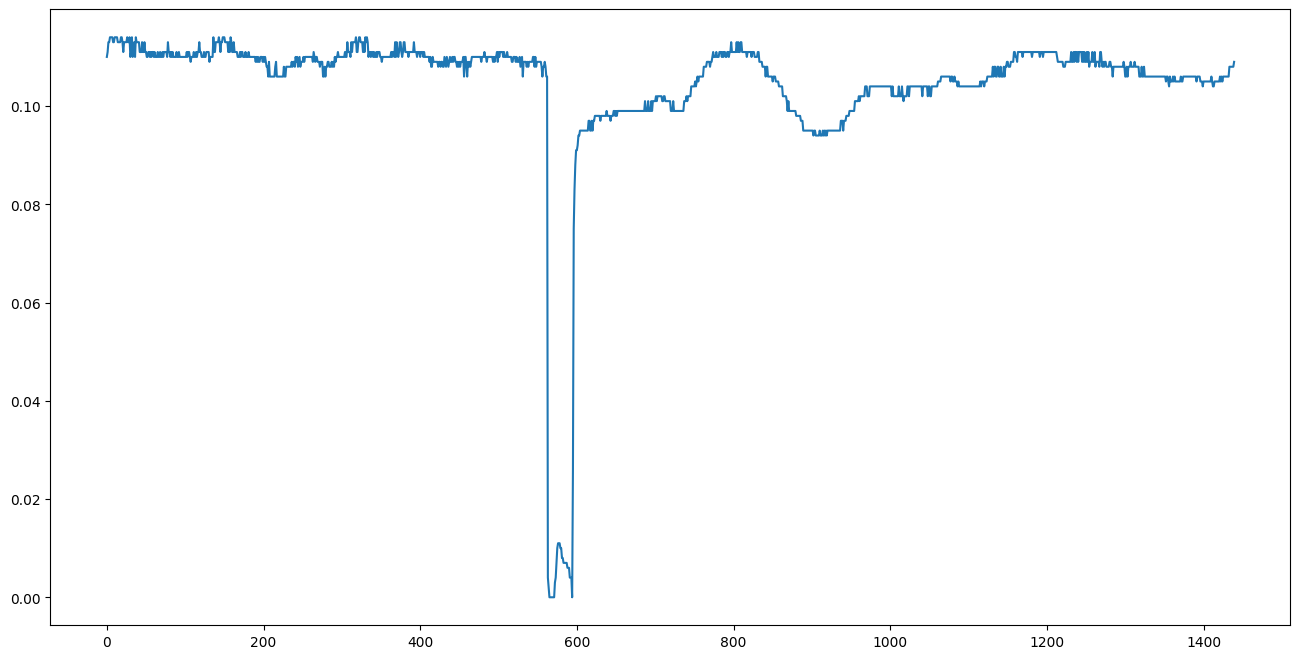

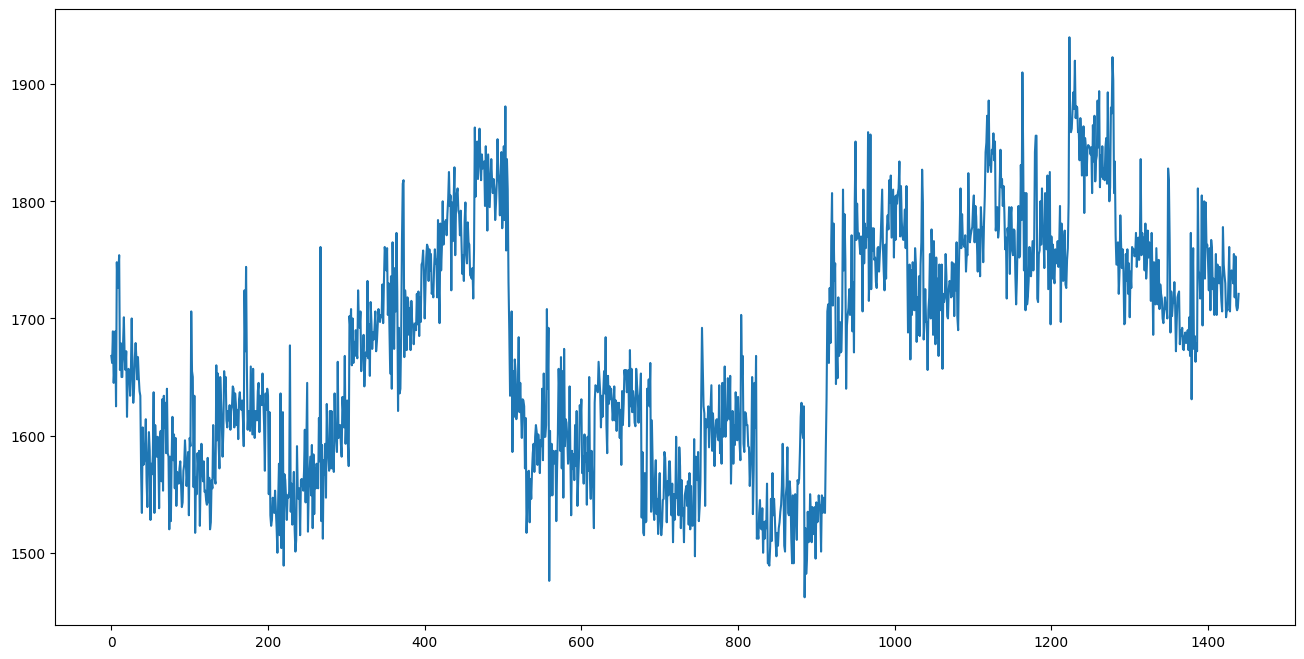

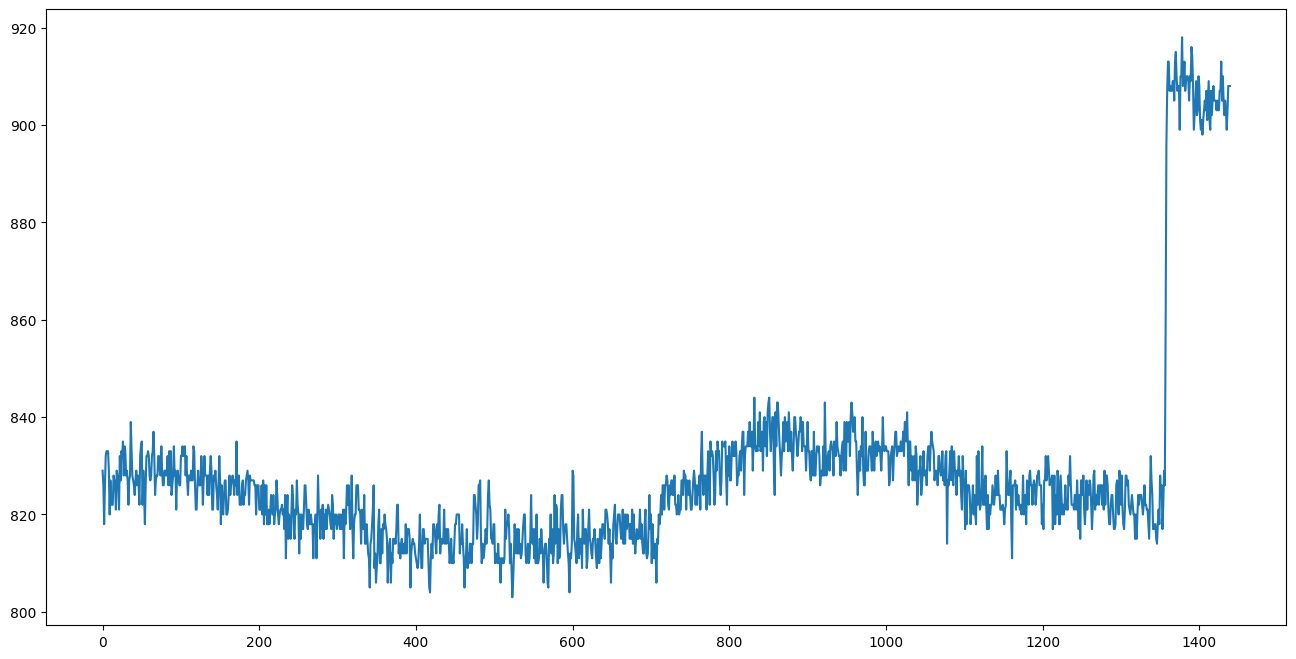

In [17]:
numeric_cols = gecco_df_complete.select_dtypes(include='number').columns.to_list()

for col in numeric_cols:
    plt.figure(figsize=(16, 8))
    plt.plot(gecco_df_complete[col].values)
    # for i in range(1, ):
    #     plt.axvline(x=i*TIME, color='r', linestyle='--', alpha=0.5)


In [18]:
17544//24

731

In [19]:
706*24, 25*24, (706*24+25*24)

(16944, 600, 17544)

### Only using data of 25 days

In [21]:
df = gecco_df_complete.iloc[:25*24, 1:11]
df_raw = df.copy()
df.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
49692,7.7,0.17,8.39,752.0,211.0,0.026,0.110,1668.0,829.0,False
49693,7.7,0.17,8.39,752.0,211.0,0.026,0.111,1662.0,826.0,False
49694,7.7,0.17,8.39,753.0,211.0,0.026,0.113,1689.0,818.0,False
49695,7.7,0.17,8.39,752.0,211.0,0.026,0.113,1645.0,826.0,False
49696,7.7,0.17,8.39,752.0,211.0,0.026,0.114,1659.0,832.0,False


In [22]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

,Tp,Cl,pH,Redox,Leit,Trueb,Cl_2,Fm,Fm_2,EVENT
49692,0.321634,0.253788,0.231379,0.268352,-0.173686,-0.616865,0.240001,0.228237,1.289386,-0.256358
49693,0.321634,0.253788,0.231379,0.268352,-0.173686,-0.616865,0.281752,0.158952,0.862359,-0.256358
49694,0.321634,0.253788,0.231379,0.281787,-0.173686,-0.616865,0.365255,0.470735,-0.276382,-0.256358
49695,0.321634,0.253788,0.231379,0.268352,-0.173686,-0.616865,0.365255,-0.037356,0.862359,-0.256358
49696,0.321634,0.253788,0.231379,0.268352,-0.173686,-0.616865,0.407006,0.124309,1.716414,-0.256358


### Smoothing using rolling mean

In [23]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [24]:
import math

SPLIT_RATIO = 0.8
TOTAL_POINTS = len(df)
PERIOD = 25
TRAIN_DAYS = math.ceil(PERIOD * SPLIT_RATIO)
TEST_DAYS = PERIOD - TRAIN_DAYS
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")
print(f"Train days: {TRAIN_DAYS}, Test days: {TEST_DAYS}")

Tensor dimensions: 25 x 24 x 10
Train days: 20, Test days: 5


In [25]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(25, 24, 10)

In [26]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (20, 24, 10)
Test tensor shape: (5, 24, 10)


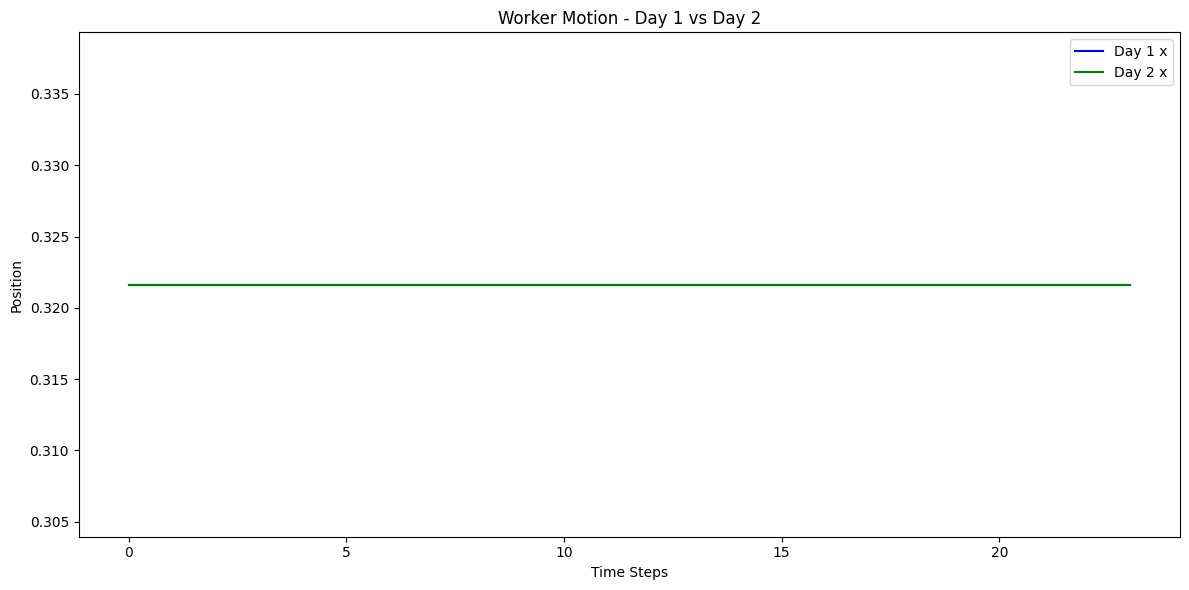

In [27]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[1, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [28]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (20, 2)
Time factors shape: (24, 2)
Feature factors shape: (10, 2)


In [29]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (20, 24, 10)
Reconstructed tensor shape: (20, 24, 10)


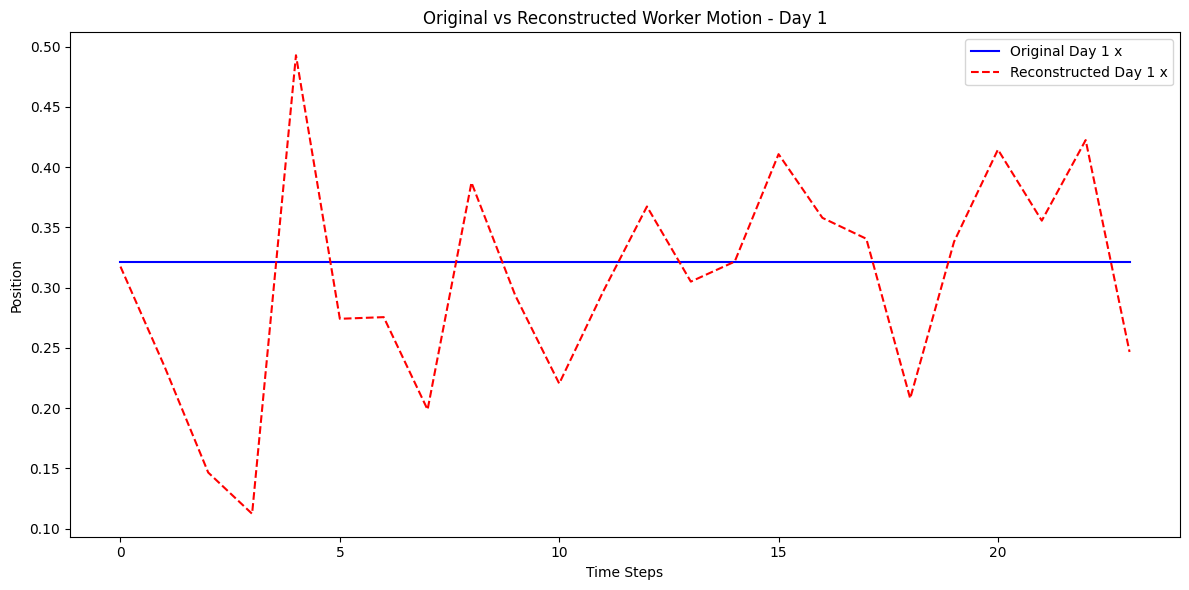

In [30]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [31]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

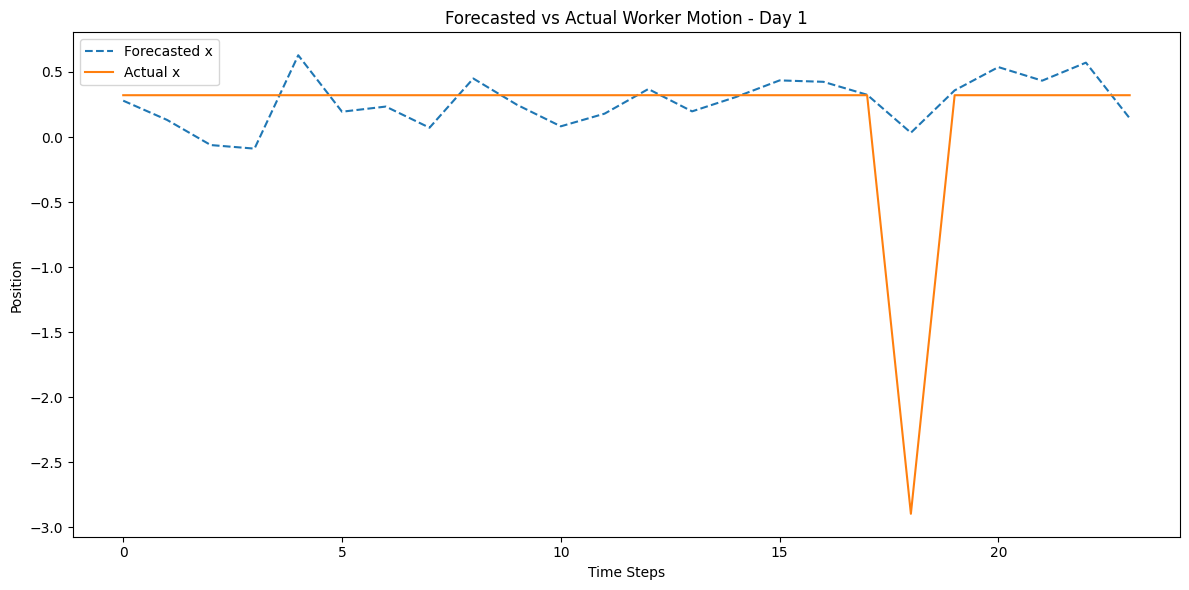

In [32]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

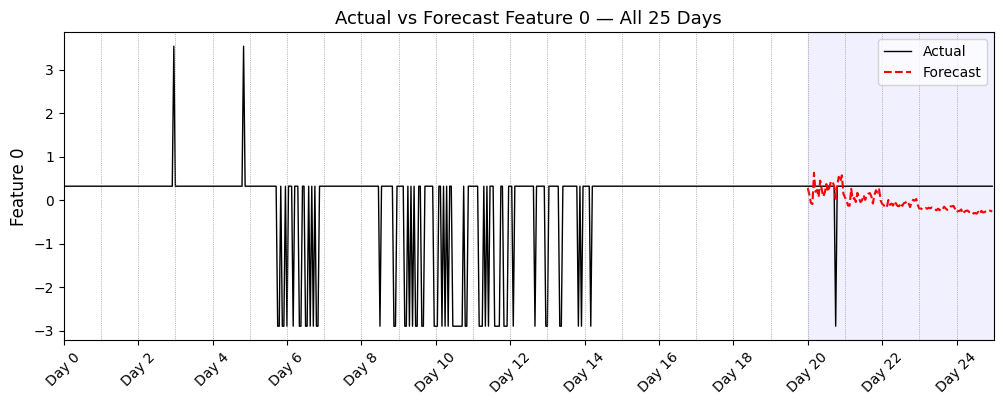

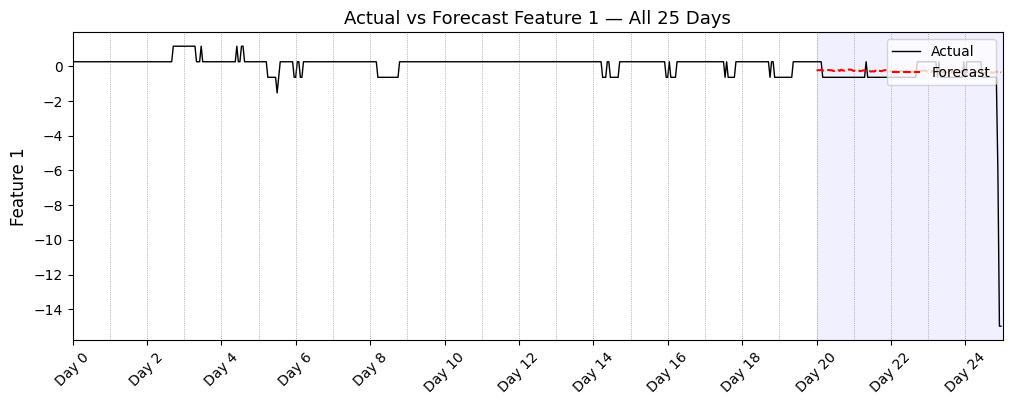

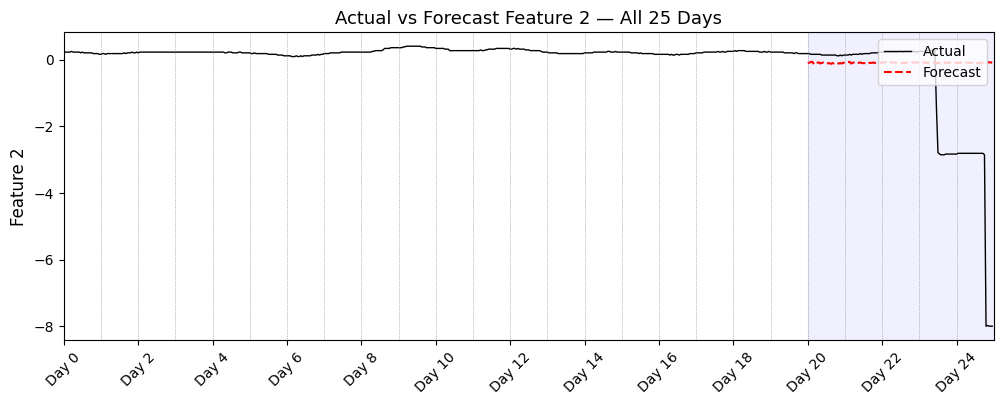

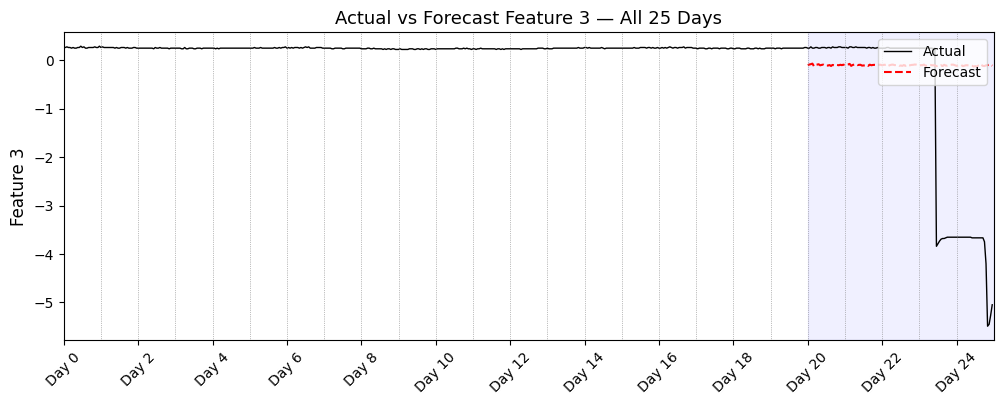

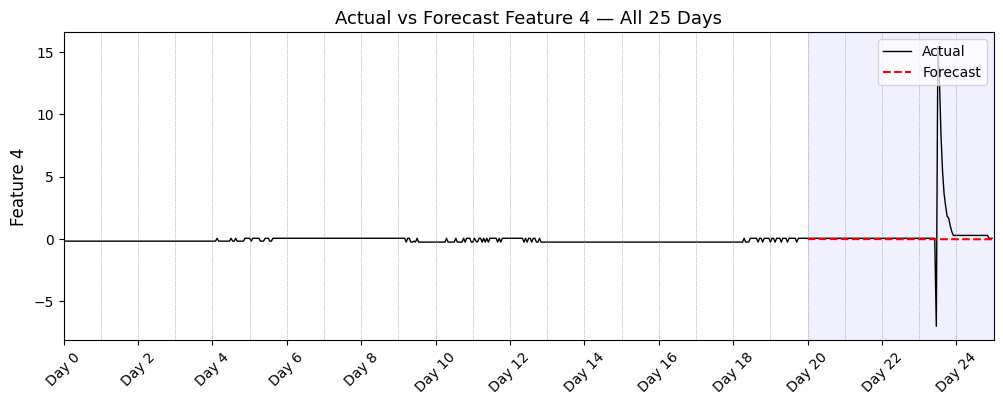

In [33]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

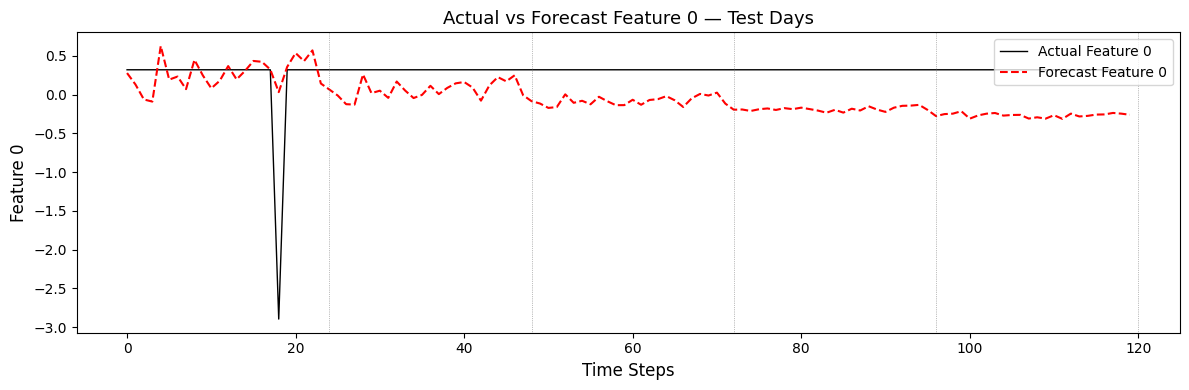

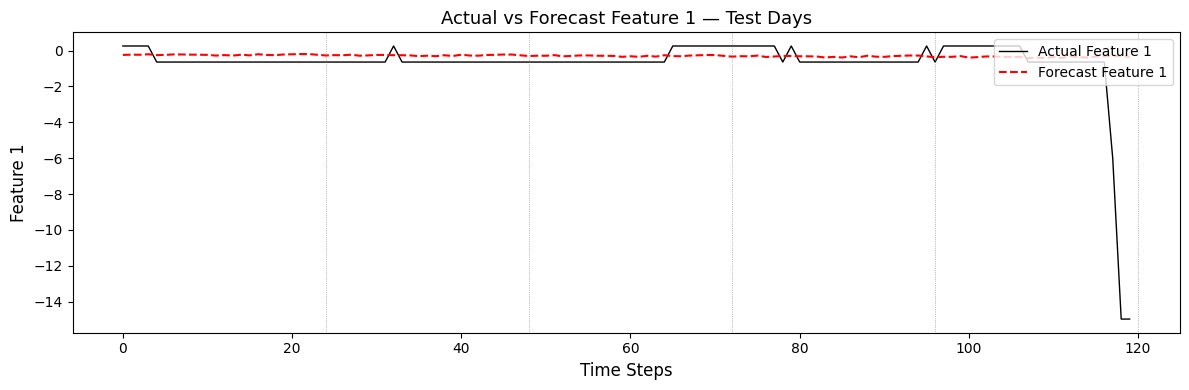

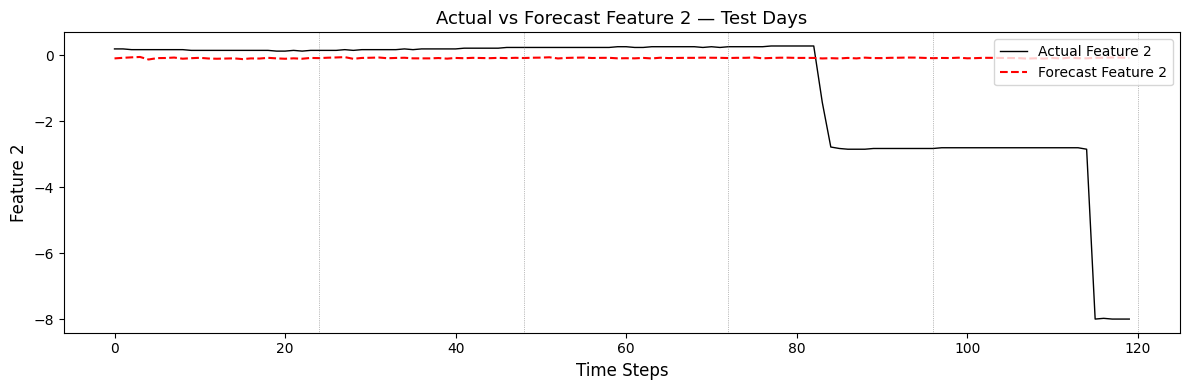

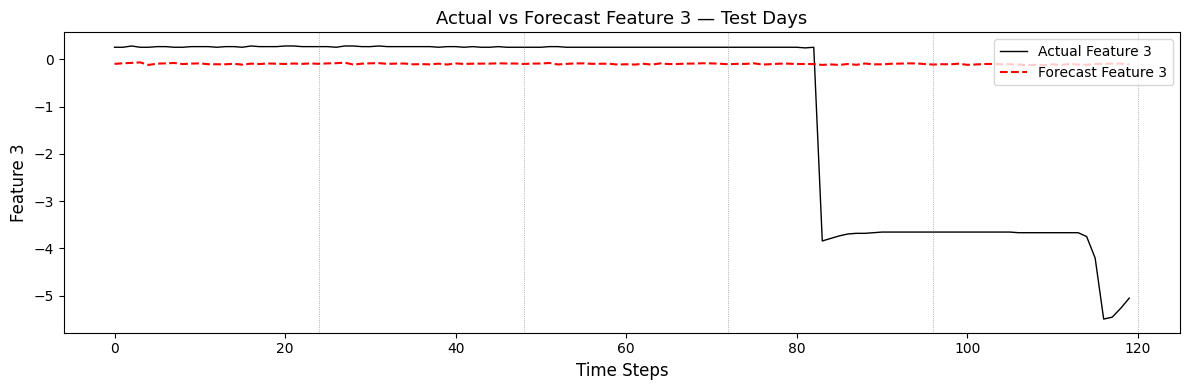

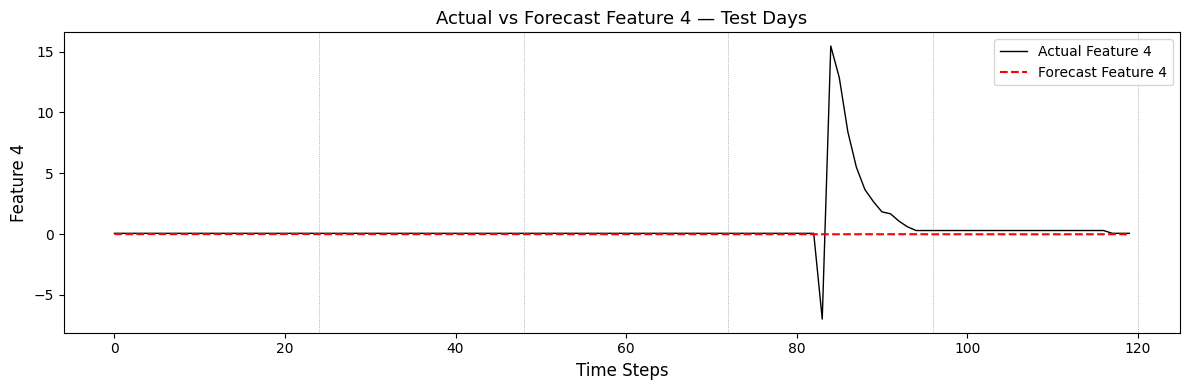

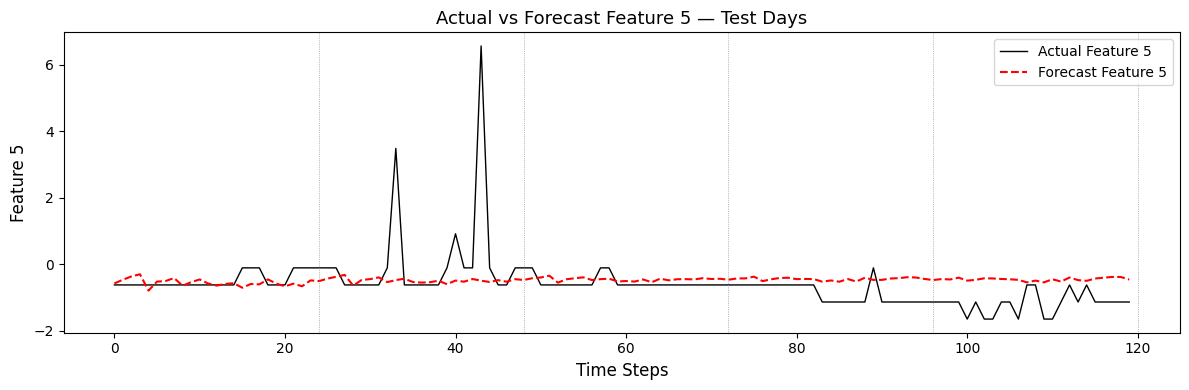

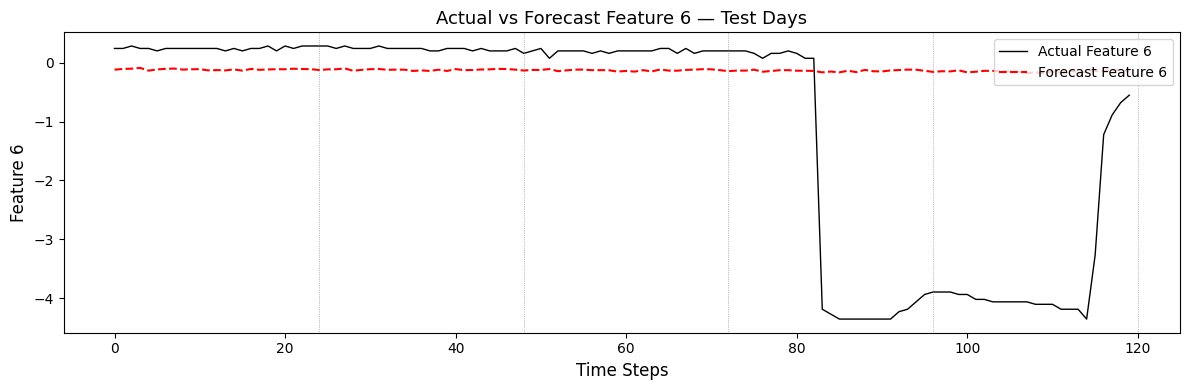

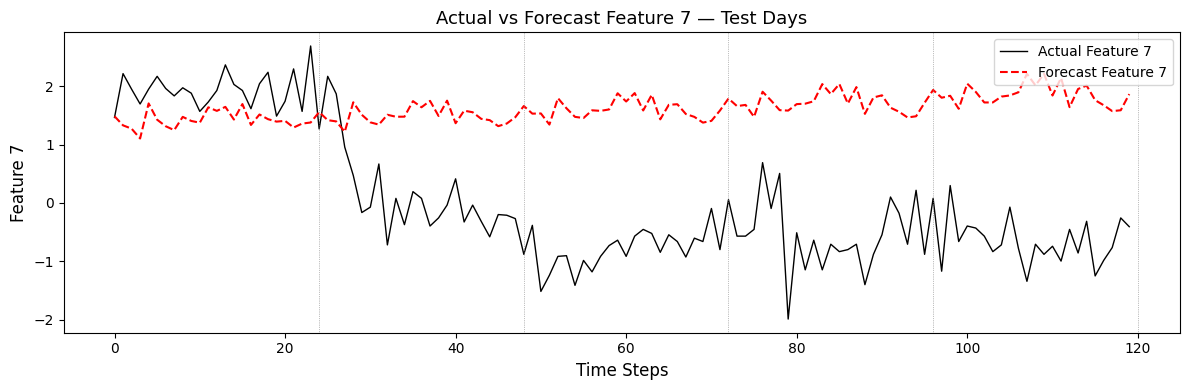

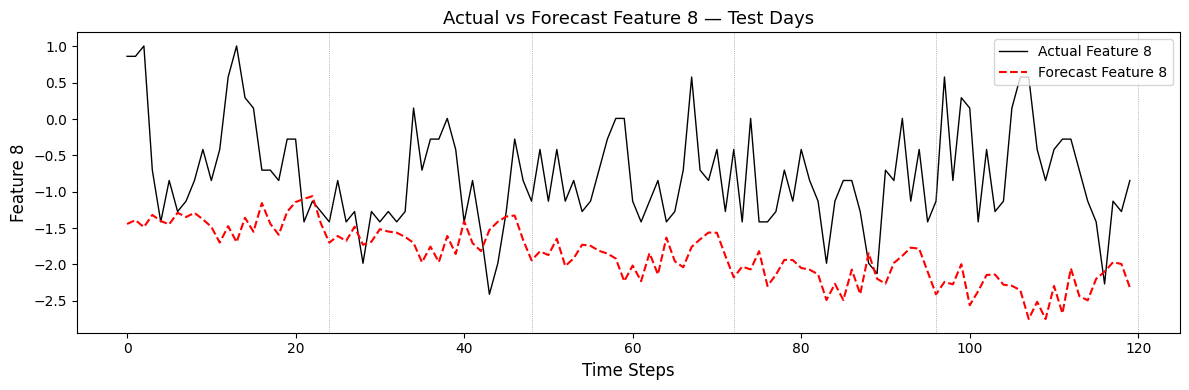

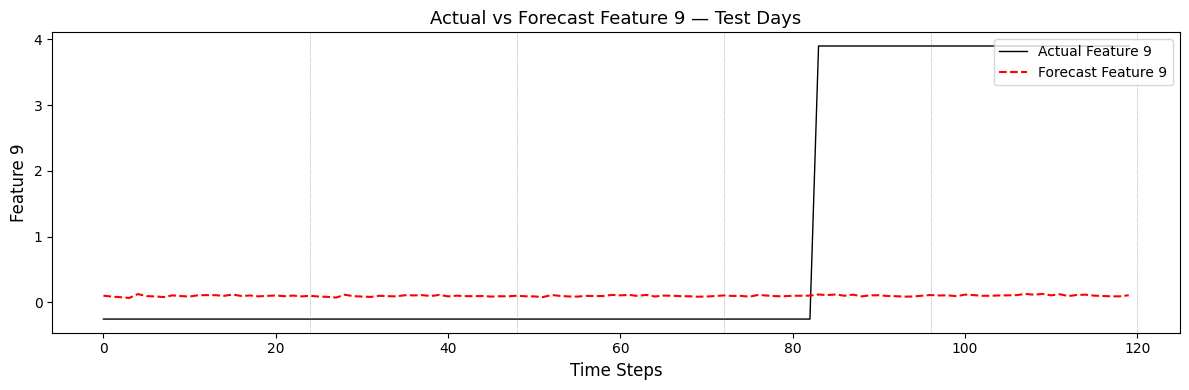

In [34]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(10):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [35]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((480, 10), (120, 10))

In [37]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: -1.8919, MSE: 0.2472, MAE: 0.4045, RMSE: 0.4972
Feature 1 R²: -0.0400, MSE: 4.0153, MAE: 0.6867, RMSE: 2.0038
Feature 2 R²: -0.1850, MSE: 4.6112, MAE: 1.2467, RMSE: 2.1474
Feature 3 R²: -0.2200, MSE: 4.5379, MAE: 1.4065, RMSE: 2.1302
Feature 4 R²: -0.0546, MSE: 4.8864, MAE: 0.6148, RMSE: 2.2105
Feature 5 R²: -0.0465, MSE: 0.7759, MAE: 0.4583, RMSE: 0.8809
Feature 6 R²: -0.1975, MSE: 4.4297, MAE: 1.3464, RMSE: 2.1047
Feature 7 R²: -2.2452, MSE: 4.0950, MAE: 1.8166, RMSE: 2.0236
Feature 8 R²: -2.6825, MSE: 1.7828, MAE: 1.1145, RMSE: 1.3352
Feature 9 R²: -0.2291, MSE: 4.5298, MAE: 1.4139, RMSE: 2.1283
average R²: -0.7792, average MSE: 3.3911, average MAE: 1.0509, average RMSE: 1.7462
